## Tutorial 6d - Dichroic Mirror Optimization for Polarization Separation

We optimize a thin-film stack to create a dichroic mirror that separates s and p polarizations near 600 nm.

This version demonstrates the operand-centric architecture in ThinFilmOptimizer with a single API entry point:
- standard spectral operands with add_operand(...)
- a custom user-defined operand registered with register_operand(...) and used through add_operand(...)

In [1]:
from optiland.thin_film.optimization import ThinFilmOptimizer
import optiland.backend as be
from optiland.thin_film import ThinFilmStack, SpectralAnalyzer
from optiland.materials import Material, IdealMaterial

SiO2 = Material("SiO2", reference="Gao")
TiO2 = Material("TiO2", reference="Zhukovsky")
BK7 = Material("N-BK7", reference="SCHOTT")
air = IdealMaterial(n=1.0)

dichroic_stack = ThinFilmStack(
    incident_material=air, 
    substrate_material=BK7, 
    reference_wl_um=0.6,
    reference_AOI_deg=45.0,
)
for i in range(10):  # 10 pairs = 20 layers
    dichroic_stack.add_layer_qwot(material=TiO2, qwot_thickness=1.0, name=f"$TiO_2$")
    dichroic_stack.add_layer_qwot(material=SiO2, qwot_thickness=1.0, name=f"$SiO_2$")

In [2]:
optimizer = ThinFilmOptimizer(dichroic_stack)

# Add all thicknesses as optimization variables
for i in range(len(dichroic_stack.layers)):
    optimizer.add_variable(
        layer_index=i,
        min_nm=30,
        max_nm=300
    )

# we want to maximize the polarization contrast (Rs-Rp) at 600 nm and 45° AOI, so we 
# minimize the negative contrast, averaged over a wavelength range to make it more 
# robust to fabrication variations. The contrast is normalized to be between 0 and 1,
# where 1 corresponds to Rs=1 and Rp=0
wl_nm = be.linspace(595, 605, 11)

# Register and add a custom operand through add_operand
def polarization_contrast(stack: ThinFilmStack, wavelength_nm: be.ndarray, aoi_deg:float):
    """Calculate the polarization contrast (Rs-Rp) averaged over a wavelength range.
    The contrast is normalized to be between 0 and 1, where 1 corresponds to Rs=1 and Rp=0."""
    rs = stack.reflectance_nm_deg(wavelength_nm, aoi_deg, "s")
    rp = stack.reflectance_nm_deg(wavelength_nm, aoi_deg, "p")
    return (1 + be.mean(rs - rp))/2

ThinFilmOptimizer.register_operand(
    "polarization_contrast", polarization_contrast, overwrite=True
)

optimizer.add_operand(
    property="polarization_contrast",
    min_val=0.99,
    input_data={"wavelength_nm": wl_nm, "aoi_deg": 45.0},
    label="Rs-Rp @ 595-605nm, 45deg",
)

# Display optimization information
optimizer.info()
contrast_initial=optimizer.rss()
print(f"Initial RSS: {contrast_initial:.6e}")

ThinFilm Optimizer Information
+--------------+---------+
| Property     |   Count |
+==============+=========+
| Stack layers |      20 |
+--------------+---------+
| Variables    |      20 |
+--------------+---------+
| Targets      |       1 |
+--------------+---------+

Variables:
+------+---------+------------------+------------+------------+
|   ID |   Layer |   Thickness (nm) |   Min (nm) |   Max (nm) |
+======+=========+==================+============+============+
|    0 |       0 |             88.2 |         30 |        300 |
+------+---------+------------------+------------+------------+
|    1 |       1 |            143.6 |         30 |        300 |
+------+---------+------------------+------------+------------+
|    2 |       2 |             88.2 |         30 |        300 |
+------+---------+------------------+------------+------------+
|    3 |       3 |            143.6 |         30 |        300 |
+------+---------+------------------+------------+------------+
|    4 |  

In [3]:
# Launch optimization
result = optimizer.optimize(
    method="L-BFGS-B",
    max_iterations=1000,
)

print(f"Merit: {result['initial_merit']:.15f} -> {result['final_merit']:.15f} in {result['iterations']} iterations")
print(f"Improvement: {result['improvement']:.15f}")

Merit: 0.093534002618582 -> 0.000329856133348 in 46 iterations
Improvement: 0.093204146485235


In [4]:
from optiland.thin_film.optimization import ThinFilmReport

report = ThinFilmReport(optimizer, result)
report.summary_table()

,Variable,Initial,Final,Change,Unit
0,Layer 0 thickness,88.2,71.4,-16.8 (-19.1%),nm
1,Layer 1 thickness,143.6,145.8,+2.2 (+1.5%),nm
2,Layer 2 thickness,88.2,78.3,-9.9 (-11.2%),nm
3,Layer 3 thickness,143.6,153.6,+10.0 (+7.0%),nm
4,Layer 4 thickness,88.2,199.6,+111.4 (+126.3%),nm
5,Layer 5 thickness,143.6,146.2,+2.6 (+1.8%),nm
6,Layer 6 thickness,88.2,74.2,-14.1 (-16.0%),nm
7,Layer 7 thickness,143.6,135.6,-8.0 (-5.6%),nm
8,Layer 8 thickness,88.2,72.0,-16.2 (-18.4%),nm
9,Layer 9 thickness,143.6,132.5,-11.1 (-7.7%),nm


<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kdani\AppData\Local\Temp\ipykernel_3984\3268724171.py:25: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel('$\lambda$ (nm)')
C:\Users\kdani\AppData\Local\Temp\ipykernel_3984\3268724171.py:38: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel('$\lambda$ (nm)')


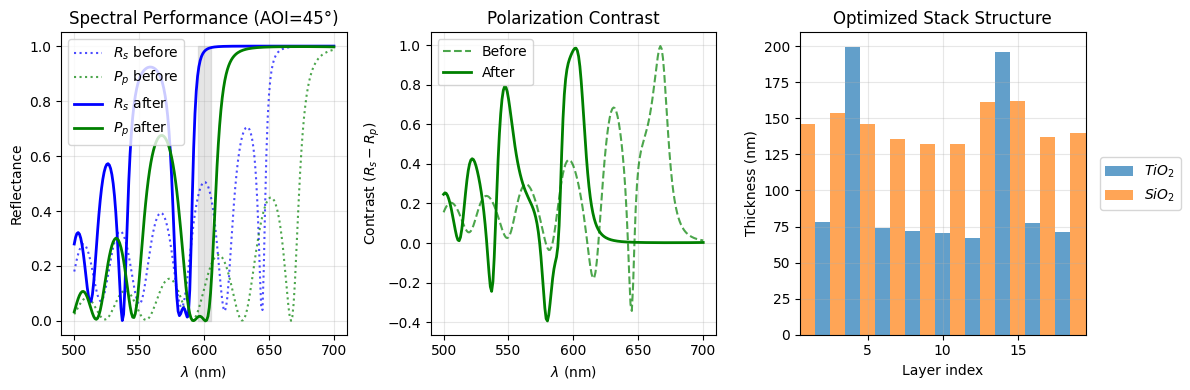

In [5]:

import matplotlib.pyplot as plt

analyzer = SpectralAnalyzer(dichroic_stack)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

wl_range = be.linspace(500, 700, 201)  # Around 600 nm

# Calculate before optimization (reset and recalculate)
optimizer.reset()
Rs_before = dichroic_stack.reflectance_nm_deg(wl_range, 45, 's')
Rp_before = dichroic_stack.reflectance_nm_deg(wl_range, 45, 'p')

# Restore optimized state
for i, var_info in enumerate(optimizer.variables):
    final_thickness = result['thickness_changes'][i]['final_nm'] / 1000  # nm → μm
    dichroic_stack.layers[i].update_thickness(final_thickness)

Rs_after = dichroic_stack.reflectance_nm_deg(wl_range, 45, 's')
Rp_after = dichroic_stack.reflectance_nm_deg(wl_range, 45, 'p')

axes[0].plot(wl_range, Rs_before, 'b:', label='$R_s$ before', alpha=0.7)
axes[0].plot(wl_range, Rp_before, 'g:', label='$P_p$ before', alpha=0.7)
axes[0].plot(wl_range, Rs_after, 'b-', label='$R_s$ after', linewidth=2)
axes[0].plot(wl_range, Rp_after, 'g-', label='$P_p$ after', linewidth=2)
axes[0].set_xlabel('$\lambda$ (nm)')
axes[0].set_ylabel('Reflectance')
axes[0].set_title('Spectral Performance (AOI=45°)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].fill_betweenx([0, 1], 595, 605, color='gray', alpha=0.2, label='Optimization Range')

# 2. Polarization contrast (Rs - Rp)
contrast_before = Rs_before - Rp_before
contrast_after = Rs_after - Rp_after

axes[1].plot(wl_range, contrast_before, 'g--', label='Before', alpha=0.7)
axes[1].plot(wl_range, contrast_after, 'g-', label='After', linewidth=2)
axes[1].set_xlabel('$\lambda$ (nm)')
axes[1].set_ylabel('Contrast ($R_s - R_p$)')
axes[1].set_title('Polarization Contrast')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Optimized stack structure
dichroic_stack.plot_structure_thickness(axes[2])
axes[2].set_title('Optimized Stack Structure')
fig.tight_layout()
